# Benchmark v5 — GPU — HIV — scaffold split, seed 0

**Task:** Binary — inhibits HIV replication (1) or not (0)
**Size:** ~41,000 molecules
**Metric:** ROC-AUC ↑
**Cluster GPU strongly recommended** for GNN/LSTM cells.
**Requires:** `./data/hiv_conformers_n25.pkl` for 3D models.

**Scaffold split**, seed **0** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_0/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "hiv"
TASK_TYPE = "classification"
OUT_CHANNELS = 1
BATCH_SIZE = 128
GNN_EPOCHS = 80
LSTM_EPOCHS = 60
TOX21_TABULAR = False

HPO_EPOCHS = 50  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 10
print(f"GPU HPO tier: xlarge — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 0

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: xlarge — 10 trials, 50 epochs/trial, batch=128
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold
SPLIT_SEED=0  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("hiv", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "hiv")
print(f"Molecules : {len(smiles)}")
print(f"Class balance: {np.bincount(y.astype(int))}  (pos rate: {y.mean():.1%})")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'hiv' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/hiv.csv
[14:48:48] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:48:49] Explicit valence for atom # 5 B, 5, is greater than permitted
[14:48:51] Explicit valence for atom # 16 Al, 9, is greater than permitted
[14:48:52] Explicit valence for atom # 4 Al, 9, is greater than permitted
[14:48:57] Explicit valence for atom # 12 Al, 7, is greater than permitted
[14:48:57] Explicit valence for atom # 13 Al, 7, is greater than permitted
[14:48:58] WARNING: not removing hydrogen atom without neighbors
[14:48:58] WARNING: not removing hydrogen atom without neighbors
[14:48:58] Explicit valence for atom # 6 Ge, 5, is greater than permitted
INFO | [hiv] 41120 / 41127 valid molecules
[14:49:32] WARNING: not removing hydrogen atom without neighbors
[14:49:32] WARNING: not removing hydrogen atom without neighbors


Molecules : 41120
Class balance: [39677  1443]  (pos rate: 3.5%)


[14:49:47] WARNING: not removing hydrogen atom without neighbors
[14:49:47] WARNING: not removing hydrogen atom without neighbors


After bond filter: 41120 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


[14:50:54] WARNING: not removing hydrogen atom without neighbors
[14:50:54] WARNING: not removing hydrogen atom without neighbors
[14:56:04] WARNING: not removing hydrogen atom without neighbors
[14:56:04] WARNING: not removing hydrogen atom without neighbors
INFO | Loaded 25905 / 26040 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/hiv_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/splits/hiv_scaffold_splits.pkl
WARNING | 12344 molecules in split have no 3D conformer (e.g. idx [26054, 26077, 26125, 26144, 26146]); excluded from 3D train/val/test subsets
WARNING | 1421 molecules in split have no 3D conformer (e.g. idx [36513, 28578, 39493, 31621, 36486]); excluded from 3D train/val/test subsets
WARNING | 1450 molecules in split have no 3D conformer (e.g. idx [31

3D graphs loaded: 25905 / 41120 (valid_idx mapping)
{'n_total': 41120, 'n_train': 32896, 'n_val': 4112, 'n_test': 4112, 'n_scaffolds_total': 19082, 'n_scaffolds_train': 10858, 'n_scaffolds_val': 4112, 'n_scaffolds_test': 4112}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/10 (layers=5, hidden=192)


→ GIN (2D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/50 | loss=0.1966 | val={'ROC-AUC': 0.6619823803501863, 'PRC-AUC': 0.2068920281724606}
INFO | HPO epoch   5/50 | loss=0.1427 | val={'ROC-AUC': 0.7395500029705575, 'PRC-AUC': 0.3379620030767928}
INFO | HPO epoch  10/50 | loss=0.1290 | val={'ROC-AUC': 0.7262779762864636, 'PRC-AUC': 0.32311241650759}
INFO | HPO epoch  15/50 | loss=0.1200 | val={'ROC-AUC': 0.731296096687404, 'PRC-AUC': 0.31226837823133824}
INFO | HPO epoch  20/50 | loss=0.1143 | val={'ROC-AUC': 0.7160995730884464, 'PRC-AUC': 0.30794409927098004}
INFO | HPO epoch  25/50 | loss=0.1041 | val={'ROC-AUC': 0.7586697843375233, 'PRC-AUC': 0.3475166626300728}
INFO | Early stop at epoch 28 (patience=15)
INFO | GIN 2D HPO — trial 1/10 finished | val=-0.777898 | best=-0.777898
INFO | GIN 2D — starting trial 2/10 (layers=4, hidden=192)
INFO | HPO epoch   1/50 | loss=0.2188 | val={'ROC-AUC': 0.6971686343073932, 'PRC-AUC': 0.21921563111879527}
INFO | HPO epoch   5/50 | loss=0.1479 | val={'ROC-AUC': 0.5343481323680436,

   scaffold test: {'ROC-AUC': 0.7311248260911767, 'PRC-AUC': 0.32241006517886595}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/10 (layers=5, hidden=192)


→ D-MPNN (2D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/50 | loss=0.3218 | val={'ROC-AUC': 0.4453417414256979, 'PRC-AUC': 0.03753777679857621}
INFO | HPO epoch   5/50 | loss=0.1553 | val={'ROC-AUC': 0.7207697138928733, 'PRC-AUC': 0.20732926770120175}
INFO | HPO epoch  10/50 | loss=0.1415 | val={'ROC-AUC': 0.7416866825662223, 'PRC-AUC': 0.28317796271858847}
INFO | HPO epoch  15/50 | loss=0.1346 | val={'ROC-AUC': 0.769410471639663, 'PRC-AUC': 0.3098050110265408}
INFO | HPO epoch  20/50 | loss=0.1290 | val={'ROC-AUC': 0.7375427548101814, 'PRC-AUC': 0.32711229696729127}
INFO | HPO epoch  25/50 | loss=0.1202 | val={'ROC-AUC': 0.7446699710582824, 'PRC-AUC': 0.3401129490270916}
INFO | HPO epoch  30/50 | loss=0.1137 | val={'ROC-AUC': 0.7513325072354294, 'PRC-AUC': 0.3371033314190706}
INFO | Early stop at epoch 30 (patience=15)
INFO | DMPNN 2D HPO — trial 1/10 finished | val=-0.769410 | best=-0.769410
INFO | DMPNN 2D — starting trial 2/10 (layers=4, hidden=192)
INFO | HPO epoch   1/50 | loss=0.2040 | val={'ROC-AUC': 0.5771559882

   scaffold test: {'ROC-AUC': 0.7542607661694761, 'PRC-AUC': 0.3082226827367126}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/10 (layers=5, hidden=192)


→ GIN (3D) (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/50 | loss=0.1716 | val={'ROC-AUC': 0.5887750251495153, 'PRC-AUC': 0.03850381895718522}
INFO | HPO epoch   5/50 | loss=0.1318 | val={'ROC-AUC': 0.7803866945245912, 'PRC-AUC': 0.32941475452974067}
INFO | HPO epoch  10/50 | loss=0.1162 | val={'ROC-AUC': 0.7794415149404703, 'PRC-AUC': 0.2802963223473935}
INFO | HPO epoch  15/50 | loss=0.1036 | val={'ROC-AUC': 0.7808012469737671, 'PRC-AUC': 0.3121761279864986}
INFO | Early stop at epoch 17 (patience=15)
INFO | GIN 3D HPO — trial 1/10 finished | val=-0.799920 | best=-0.799920
INFO | GIN 3D — starting trial 2/10 (layers=4, hidden=192)
INFO | HPO epoch   1/50 | loss=0.2327 | val={'ROC-AUC': 0.5267635061187941, 'PRC-AUC': 0.0786769921968225}
INFO | HPO epoch   5/50 | loss=0.1378 | val={'ROC-AUC': 0.6572425076554019, 'PRC-AUC': 0.1392096964750202}
INFO | HPO epoch  10/50 | loss=0.1280 | val={'ROC-AUC': 0.6246421030522116, 'PRC-AUC': 0.07461906227015723}
INFO | HPO epoch  15/50 | loss=0.1251 | val={'ROC-AUC': 0.57844437811605

   scaffold test: {'ROC-AUC': 0.6749843629715165, 'PRC-AUC': 0.2891048392190308}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


→ SchNet (3D coords) (Optuna 10 trials, scaffold split) …


INFO | SchNet — starting trial 1/10
INFO | HPO epoch   1/50 | loss=0.1761 | val={'ROC-AUC': 0.4902718358593396, 'PRC-AUC': 0.08946176953203692}
INFO | HPO epoch   5/50 | loss=0.1406 | val={'ROC-AUC': 0.4909074829480759, 'PRC-AUC': 0.0774605020854695}
INFO | HPO epoch  10/50 | loss=0.1388 | val={'ROC-AUC': 0.5901458119147901, 'PRC-AUC': 0.14254591541482217}
INFO | HPO epoch  15/50 | loss=0.1363 | val={'ROC-AUC': 0.6008246830055605, 'PRC-AUC': 0.14577378907273336}
INFO | HPO epoch  20/50 | loss=0.1332 | val={'ROC-AUC': 0.6537713218143028, 'PRC-AUC': 0.15496624288390248}
INFO | HPO epoch  25/50 | loss=0.1314 | val={'ROC-AUC': 0.6823478039774925, 'PRC-AUC': 0.1866746529521584}
INFO | HPO epoch  30/50 | loss=0.1311 | val={'ROC-AUC': 0.6916669430349661, 'PRC-AUC': 0.21937763402164553}
INFO | HPO epoch  35/50 | loss=0.1323 | val={'ROC-AUC': 0.6478404581080932, 'PRC-AUC': 0.19443295969226107}
INFO | HPO epoch  40/50 | loss=0.1303 | val={'ROC-AUC': 0.6634055207331498, 'PRC-AUC': 0.2029456204470

   scaffold test: {'ROC-AUC': 0.673709343725943, 'PRC-AUC': 0.2142234160608148}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/10


→ SMILES LSTM (Optuna 10 trials, scaffold split) …


INFO | HPO epoch   1/50 | loss=0.2317 | val={'ROC-AUC': 0.608760598524906, 'PRC-AUC': 0.03884173094438032}
INFO | HPO epoch   5/50 | loss=0.1475 | val={'ROC-AUC': 0.7246144640689848, 'PRC-AUC': 0.1720549743810493}
INFO | HPO epoch  10/50 | loss=0.1317 | val={'ROC-AUC': 0.7733040238323587, 'PRC-AUC': 0.2631703521434673}
INFO | HPO epoch  15/50 | loss=0.1244 | val={'ROC-AUC': 0.7994406864534088, 'PRC-AUC': 0.30885543616240524}
INFO | HPO epoch  20/50 | loss=0.1189 | val={'ROC-AUC': 0.78248729025742, 'PRC-AUC': 0.3177652912796066}
INFO | HPO epoch  25/50 | loss=0.1147 | val={'ROC-AUC': 0.7911782928630234, 'PRC-AUC': 0.36866873822688523}
INFO | HPO epoch  30/50 | loss=0.1099 | val={'ROC-AUC': 0.7601762813712093, 'PRC-AUC': 0.34829789498048397}
INFO | Early stop at epoch 30 (patience=15)
INFO | LSTM HPO — trial 1/10 finished | val=-0.799441 | best=-0.799441
INFO | LSTM — starting trial 2/10
INFO | HPO epoch   1/50 | loss=0.1726 | val={'ROC-AUC': 0.6637350092936015, 'PRC-AUC': 0.057269146479

   scaffold test: {'ROC-AUC': 0.7314776992267124, 'PRC-AUC': 0.2674360958478847}


### Finalize GPU + merge


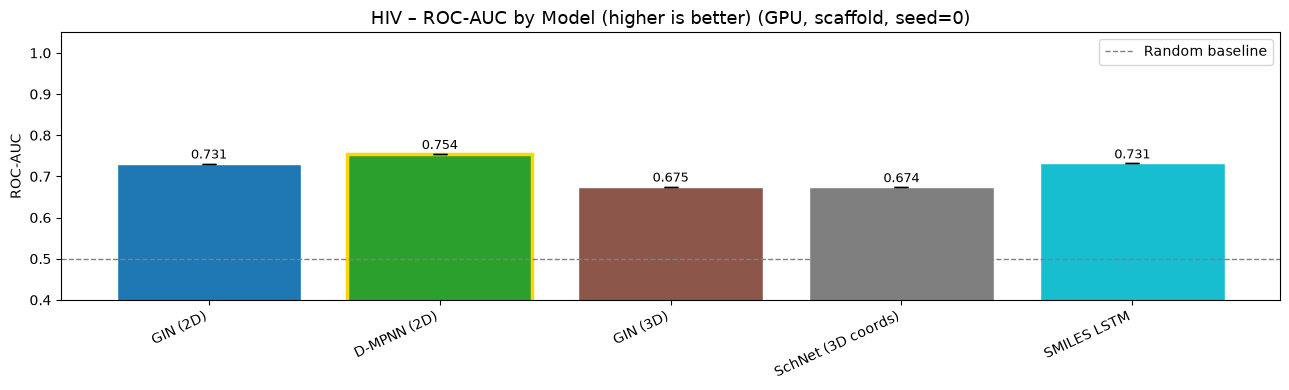

=== HIV Results (5/12 models) ===
                            ROC-AUC          PRC-AUC
Model                                               
GIN (2D)            0.7311 ± 0.0000  0.3224 ± 0.0000
D-MPNN (2D)         0.7543 ± 0.0000  0.3082 ± 0.0000
GIN (3D)            0.6750 ± 0.0000  0.2891 ± 0.0000
SchNet (3D coords)  0.6737 ± 0.0000  0.2142 ± 0.0000
SMILES LSTM         0.7315 ± 0.0000  0.2674 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/hiv_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/hiv_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/hiv_partial.json


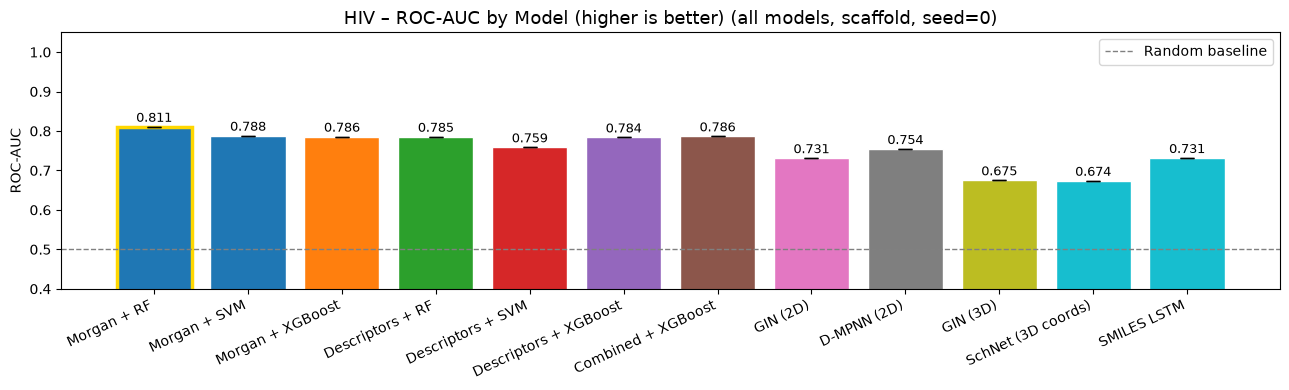

=== HIV Results (12/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.8106 ± 0.0000  0.3689 ± 0.0000
Morgan + SVM           0.7880 ± 0.0000  0.3134 ± 0.0000
Morgan + XGBoost       0.7855 ± 0.0000  0.3562 ± 0.0000
Descriptors + RF       0.7853 ± 0.0000  0.3555 ± 0.0000
Descriptors + SVM      0.7586 ± 0.0000  0.2864 ± 0.0000
Descriptors + XGBoost  0.7836 ± 0.0000  0.3515 ± 0.0000
Combined + XGBoost     0.7864 ± 0.0000  0.3779 ± 0.0000
GIN (2D)               0.7311 ± 0.0000  0.3224 ± 0.0000
D-MPNN (2D)            0.7543 ± 0.0000  0.3082 ± 0.0000
GIN (3D)               0.6750 ± 0.0000  0.2891 ± 0.0000
SchNet (3D coords)     0.6737 ± 0.0000  0.2142 ± 0.0000
SMILES LSTM            0.7315 ± 0.0000  0.2674 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/combined/hiv_results.csv
Plot    

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"HIV – ROC-AUC by Model (higher is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"HIV – ROC-AUC by Model (higher is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
else:
    print("Run CPU notebook first for combined results.")
